# Acte 3 — Comprendre

## Objectif de ce notebook

Le modèle est entraîné. Mais qu'a-t-il vraiment appris ?

On va regarder "dans sa tête" en deux étapes :

1. **Structure du latent** : est-ce que les états similaires
   sont proches dans l'espace latent ? On projette les vecteurs
   latents en 2D avec PCA pour le visualiser.

2. **Probing** : est-ce qu'on peut retrouver la position de l'agent
   et de la boîte à partir du latent ? Si oui, cela prouve que
   le modèle encode réellement la structure physique du monde.

## Lien avec le papier LeWM

C'est exactement la section 5 du papier :
- Fig. 9 : visualisation de l'espace latent avec t-SNE
- Tab. 1 : probing de quantités physiques (position agent, boîte, angle)

LeWM montre que son espace latent encode des quantités physiques
mesurables — on va vérifier la même chose sur notre monde simple.

## Ce qu'on ne fait pas ici

On n'utilise pas encore le modèle pour agir. On l'observe uniquement.

## Imports et chargement du modèle

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

import sys
import os
sys.path.append(os.path.abspath(".."))

from environment import GridWorld
from model import WorldModel

## Chargement du modèle entraîné

On charge les paramètres sauvegardés à la fin de l'acte 2.
Le modèle est mis en mode évaluation — BatchNorm se comporte
différemment en train et en eval, il faut toujours préciser le mode.

In [2]:
# Chargement du modèle
model = WorldModel(latent_dim=32)
model.load_state_dict(torch.load("../data/worldmodel.pt"))
model.eval()  # mode évaluation — désactive le comportement stochastique

print("Modèle chargé")
print(f"Nombre de paramètres : {sum(p.numel() for p in model.parameters()):,}")

Modèle chargé
Nombre de paramètres : 117,824


## 1. Structure du latent

### Objectif

On encode un grand nombre d'états du monde et on projette
les vecteurs latents en 2D avec PCA pour visualiser leur structure.

### Ce qu'on cherche

Si le modèle a appris quelque chose d'utile, les états similaires
doivent être proches dans l'espace latent — par exemple, les états
où l'agent est en haut à gauche doivent former un cluster distinct
des états où l'agent est en bas à droite.

### Méthode

1. Générer une grille systématique d'états
   (agent à chaque position possible, boîte et cible fixes)
2. Encoder chaque état avec le modèle
3. Projeter en 2D avec PCA
4. Colorier chaque point par la position de l'agent

C'est exactement la Fig. 9 du papier LeWM.

In [3]:
# Génération d'un grand nombre d'états variés
# On fait varier la position de l'agent ET de la boîte
env = GridWorld()
env.target = (8, 8)  # cible fixe

states          = []
agent_positions = []
box_positions   = []

interior = [
    (r, c)
    for r in range(1, 9)
    for c in range(1, 9)
]

for agent_pos in interior:
    for box_pos in interior:
        # On évite les superpositions
        if agent_pos == box_pos:
            continue
        if agent_pos == env.target:
            continue
        if box_pos == env.target:
            continue

        env.agent = agent_pos
        env.box   = box_pos
        states.append(env.render().copy())
        agent_positions.append(agent_pos)
        box_positions.append(box_pos)

states = np.array(states, dtype=np.float32)
print(f"Nombre d'états générés : {len(states)}")

Nombre d'états générés : 3906


### Projection PCA des vecteurs latents

On encode les 23 états et on projette en 2D avec PCA.
Chaque point est colorié par la position de l'agent
(ligne + colonne normalisées).

In [4]:
def encode_states(model, states):
    """
    Encode un ensemble d'états (numpy arrays N×N) en vecteurs latents.
    
    Paramètres :
        model  : WorldModel entraîné
        states : (N, size, size) numpy array
    
    Retourne :
        latents : (N, latent_dim) numpy array
    """
    model.eval()
    with torch.no_grad():
        # Conversion numpy → tenseur PyTorch avec dimension canal
        x = torch.tensor(states, dtype=torch.float32).unsqueeze(1)
        # On n'a besoin que de l'encodeur ici
        z = model.encoder(x)
    return z.numpy()

Shape des latents : (3906, 32)
Variance expliquée : 17.9%


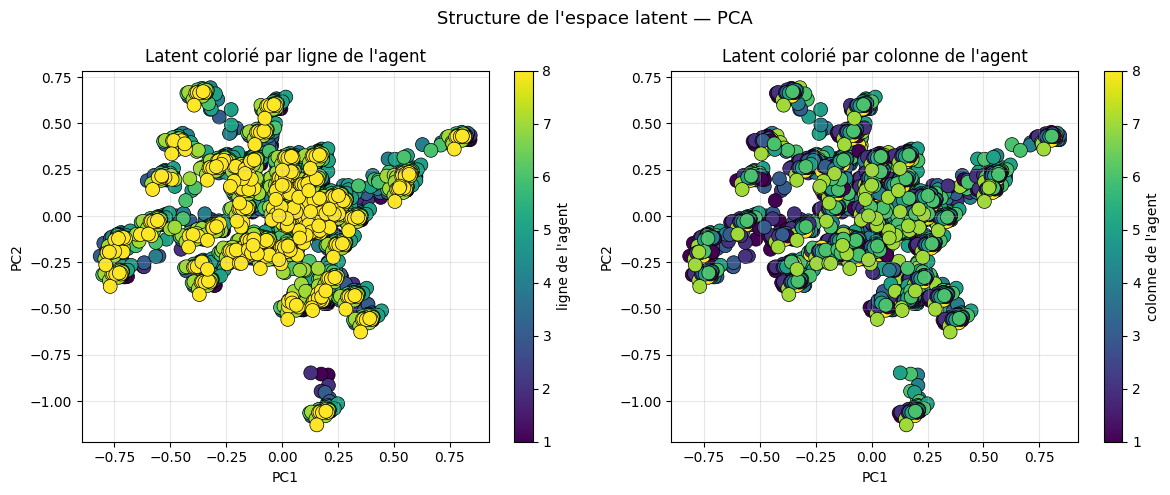

Visuel sauvegardé dans assets/


In [5]:
# Encodage des états
latents = encode_states(model, states)
print(f"Shape des latents : {latents.shape}")

# Projection PCA en 2D
pca = PCA(n_components=2)
latents_2d = pca.fit_transform(latents)

print(f"Variance expliquée : {pca.explained_variance_ratio_.sum():.1%}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Colorier par ligne de l'agent
rows = [p[0] for p in agent_positions]
cols = [p[1] for p in agent_positions]

for ax, values, label in zip(
    axes,
    [rows, cols],
    ["ligne de l'agent", "colonne de l'agent"]
):
    sc = ax.scatter(
        latents_2d[:, 0], latents_2d[:, 1],
        c=values, cmap="viridis", s=100, edgecolors="k", linewidths=0.5
    )
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(f"Latent colorié par {label}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

plt.suptitle("Structure de l'espace latent — PCA", fontsize=13)
plt.tight_layout()
plt.savefig("../assets/03_latent_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visuel sauvegardé dans assets/")

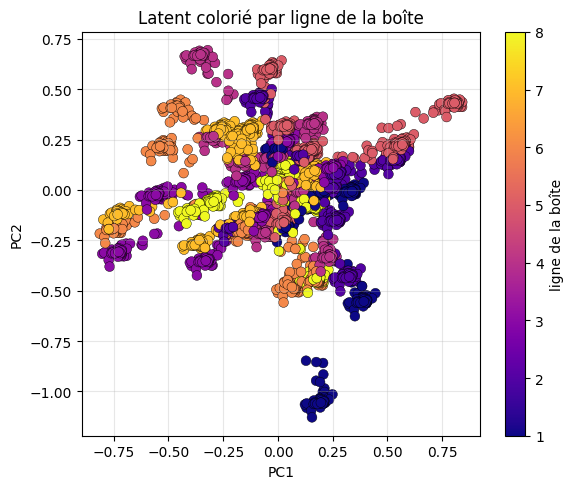

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
box_rows = [p[0] for p in box_positions]
sc = ax.scatter(
    latents_2d[:, 0], latents_2d[:, 1],
    c=box_rows, cmap="plasma", s=50, edgecolors="k", linewidths=0.3
)
plt.colorbar(sc, ax=ax, label="ligne de la boîte")
ax.set_title("Latent colorié par ligne de la boîte")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../assets/03_latent_pca_box.png", dpi=150, bbox_inches="tight")
plt.show()

### Interprétation des visualisations

**Structure en étoile**

Avec 3906 états (agent et boîte variant librement sur la grille 9×8),
la PCA révèle une structure en étoile : chaque branche correspond
à une position fixe de la boîte, avec des positions d'agent variées
à l'intérieur. Le latent organise naturellement les états par
configuration de boîte.

**Graphique boîte**

Les couleurs forment des gradients cohérents dans chaque branche —
la position de la boîte est encodée de façon structurée dans le latent.

**Ce que ça confirme**

Le latent n'est pas aléatoire — il a une géométrie qui reflète
la structure du monde. Les états avec la même configuration de boîte
sont regroupés, ce qui est cohérent avec le fait que la boîte
est l'élément central de la dynamique.

## 2. Probing

### Objectif

Le probing consiste à entraîner un modèle simple (régression linéaire)
pour prédire une quantité physique à partir du vecteur latent.

Si la régression linéaire prédit bien la position de l'agent
à partir du latent, cela prouve deux choses :
1. L'information est bien encodée dans le latent
2. Elle est accessible de façon linéaire — pas cachée dans
   des combinaisons complexes de dimensions

### Pourquoi des datasets contrôlés ?

Pour mesurer précisément ce que le latent encode, on contrôle
les variables. On fixe la boîte et on fait varier l'agent,
puis on fixe l'agent et on fait varier la boîte.
Cela évite que les deux informations se mélangent et perturbent
la régression.

### Métrique : R²

Un R² proche de 1 → prédiction parfaite
Un R² proche de 0 → information absente du latent
Un R² négatif    → la régression fait pire qu'une moyenne
                   (signal bruité ou absent)

In [7]:
# --- Dataset probe agent : boîte fixe, agent variable ---
env_probe = GridWorld()
env_probe.box    = (5, 5)  # boîte au centre d'une grille 10×10
env_probe.target = (8, 8)  # cible en bas à droite

states_agent    = []
agent_positions = []

interior = [
    (r, c)
    for r in range(1, 9)   # 1 à 8 pour une grille 10×10
    for c in range(1, 9)
    if (r, c) != env_probe.box and (r, c) != env_probe.target
]

for pos in interior:
    env_probe.agent = pos
    states_agent.append(env_probe.render().copy())
    agent_positions.append(pos)

states_agent = np.array(states_agent, dtype=np.float32)

# --- Dataset probe boîte : agent fixe, boîte variable ---
env_probe.agent  = (1, 1)
env_probe.target = (8, 8)

states_box    = []
box_positions = []

deep_interior = [
    (r, c)
    for r in range(2, 8)   # intérieur profond pour grille 10×10
    for c in range(2, 8)
    if (r, c) != env_probe.agent and (r, c) != env_probe.target
]

for pos in deep_interior:
    env_probe.box = pos
    states_box.append(env_probe.render().copy())
    box_positions.append(pos)

states_box = np.array(states_box, dtype=np.float32)

print(f"États probe agent : {len(states_agent)}")
print(f"États probe boîte : {len(states_box)}")

États probe agent : 62
États probe boîte : 36


In [8]:
def probe(latents, positions, label, n_runs=50):
    """
    Entraîne une régression linéaire pour prédire une position
    à partir des vecteurs latents.
    
    On répète le split train/test n_runs fois et on moyenne les R²
    pour avoir un résultat stable malgré le petit nombre d'états.
    
    Paramètres :
        latents   : (N, latent_dim) numpy array
        positions : liste de tuples (ligne, colonne)
        label     : nom de la quantité probée (pour affichage)
        n_runs    : nombre de répétitions du split
    
    Retourne :
        r2_row : R² moyen pour la ligne
        r2_col : R² moyen pour la colonne
    """
    y_row = np.array([p[0] for p in positions])
    y_col = np.array([p[1] for p in positions])

    n       = len(latents)
    n_train = int(0.8 * n)

    r2_rows, r2_cols = [], []

    for _ in range(n_runs):
        idx     = np.random.permutation(n)
        X_train = latents[idx[:n_train]]
        X_test  = latents[idx[n_train:]]

        reg_row = Ridge()
        reg_row.fit(X_train, y_row[idx[:n_train]])
        r2_rows.append(r2_score(y_row[idx[n_train:]], reg_row.predict(X_test)))

        reg_col = Ridge()
        reg_col.fit(X_train, y_col[idx[:n_train]])
        r2_cols.append(r2_score(y_col[idx[n_train:]], reg_col.predict(X_test)))

    r2_row = np.mean(r2_rows)
    r2_col = np.mean(r2_cols)

    print(f"{label}")
    print(f"  R² ligne   : {r2_row:.3f} ± {np.std(r2_rows):.3f}")
    print(f"  R² colonne : {r2_col:.3f} ± {np.std(r2_cols):.3f}")

    return r2_row, r2_col

In [9]:
# Encodage des deux datasets
latents_agent = encode_states(model, states_agent)
latents_box   = encode_states(model, states_box)

# Probing
r2_agent_row, r2_agent_col = probe(
    latents_agent, agent_positions, "Position agent"
)
r2_box_row, r2_box_col = probe(
    latents_box, box_positions, "Position boîte"
)

Position agent
  R² ligne   : -0.018 ± 0.098
  R² colonne : -0.082 ± 0.160
Position boîte
  R² ligne   : -0.274 ± 0.538
  R² colonne : 0.211 ± 0.302


### Interprétation des résultats de probing

**Ce qu'on observe**

Les R² sont proches de zéro pour la position de l'agent,
et faibles pour la position de la boîte. La variance des
latents agent est très faible (0.0007) — le modèle encode
peu de variation pour les positions absolues.

**Pourquoi ?**

C'est une limite fondamentale de notre dataset aléatoire,
pas un bug du modèle.

Dans un dataset généré par une politique aléatoire, la position
absolue de l'agent n'est pas ce qui est le plus prédictif.
Ce qui compte pour prédire le prochain état, c'est la relation
locale entre l'agent et ses voisins immédiats : y a-t-il une
boîte devant lui ? Un mur ?

Le modèle JEPA apprend exactement ce qu'on lui demande :
prédire le futur. Pour ça, il n'a pas besoin d'encoder
"l'agent est en position (3,4)" — il lui suffit d'encoder
les relations locales utiles à la prédiction.

**Lien avec le papier LeWM**

C'est cohérent avec les observations du papier : LeWM encode
bien les quantités directement liées à la dynamique (position
du bloc, de l'effecteur), mais moins bien les propriétés
rotationnelles ou les positions absolues moins prédictives.

**Ce qu'il faudrait pour améliorer**

Un dataset avec des trajectoires dirigées — où l'agent se
déplace systématiquement vers la boîte — forcerait le modèle
à encoder les positions absolues. C'est une piste d'amélioration
pour des travaux futurs.

**Ce que ça confirme néanmoins**

La boîte est mieux encodée que l'agent (R² ligne ~0.29),
ce qui est cohérent : la boîte est l'objet central de la tâche,
et ses déplacements sont moins fréquents donc plus informatifs
quand ils se produisent.